# 3. Iris KNN - 입력 데이터 구성별 성능 비교

동일한 KNN 모델로 입력 데이터를 다르게 줬을 때 성능이 어떻게 달라지는지 비교한다.

비교 대상
- 4D (scaled): 4개 피처 전체, StandardScaler 적용
- 2D (sepal_width + petal_width): 피처 2개만 선택
- PCA PC1-PC2: 4D → 2차원 축소
- PCA PC1-PC3: 4D → 3차원 축소
- PCA PC1-PC4: 4D → 4차원 (전체 주성분)

## 1. 패키지

In [1]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

## 2. 데이터 준비

In [2]:
iris = load_iris()

FEATURES = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
COLORS   = {'Setosa': '#E74C3C', 'Versicolor': '#3498DB', 'Virginica': '#2ECC71'}

df = pd.DataFrame(iris.data, columns=FEATURES)
df['species']      = iris.target
df['species_name'] = df['species'].map({0:'Setosa', 1:'Versicolor', 2:'Virginica'})

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [3]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
species_name    0
dtype: int64

## 3. EDA

In [5]:
# 왜도 / 첨도 / IQR 이상치
stat = pd.DataFrame({
    'mean':     df[FEATURES].mean(),
    'std':      df[FEATURES].std(),
    'skewness': df[FEATURES].skew(),
    'kurtosis': df[FEATURES].kurtosis(),
}).round(3)

outlier_cnt = {}
for f in FEATURES:
    Q1, Q3 = df[f].quantile(0.25), df[f].quantile(0.75)
    IQR = Q3 - Q1
    outlier_cnt[f] = int(((df[f] < Q1-1.5*IQR) | (df[f] > Q3+1.5*IQR)).sum())
stat['outliers(IQR)'] = pd.Series(outlier_cnt)
print(stat)

               mean    std  skewness  kurtosis  outliers(IQR)
sepal_length  5.843  0.828     0.315    -0.552              0
sepal_width   3.057  0.436     0.319     0.228              4
petal_length  3.758  1.765    -0.275    -1.402              0
petal_width   1.199  0.762    -0.103    -1.341              0


In [6]:
df.groupby('species_name')[FEATURES].mean().round(3)

,sepal_length,sepal_width,petal_length,petal_width
species_name,,,,
Setosa,5.006,3.428,1.462,0.246
Versicolor,5.936,2.770,4.260,1.326
Virginica,6.588,2.974,5.552,2.026


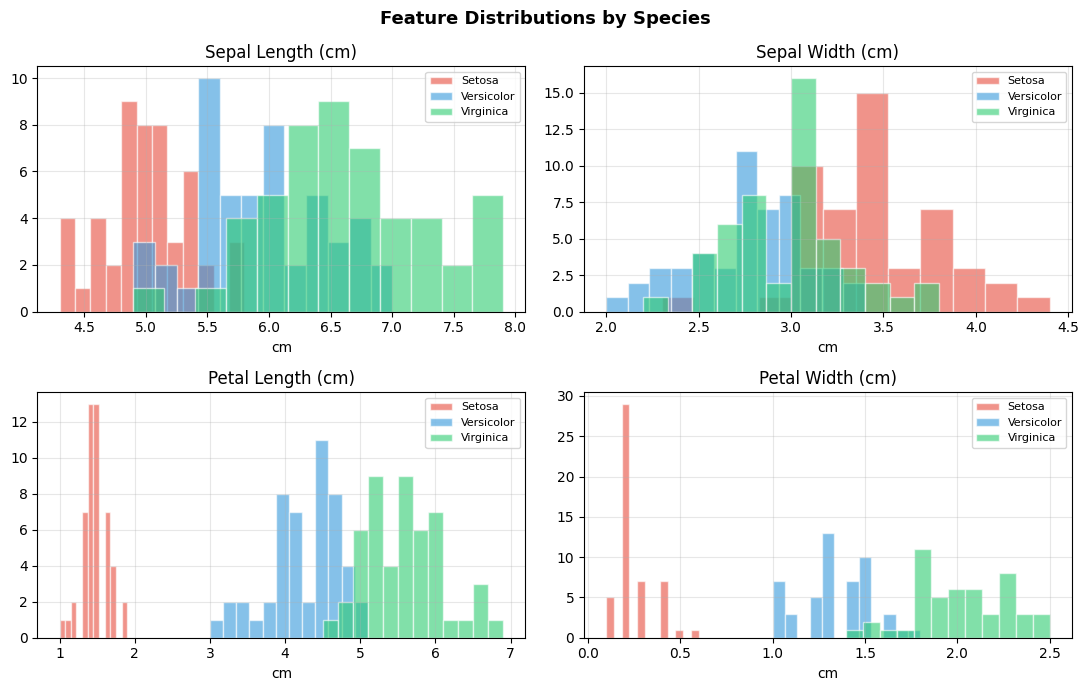

In [7]:
# 히스토그램
feat_labels = ['Sepal Length (cm)', 'Sepal Width (cm)', 'Petal Length (cm)', 'Petal Width (cm)']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, feat, label in zip(axes.flatten(), FEATURES, feat_labels):
    for sp, color in COLORS.items():
        ax.hist(df[df['species_name']==sp][feat], bins=12,
                alpha=0.6, color=color, label=sp, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('cm')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle('Feature Distributions by Species', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

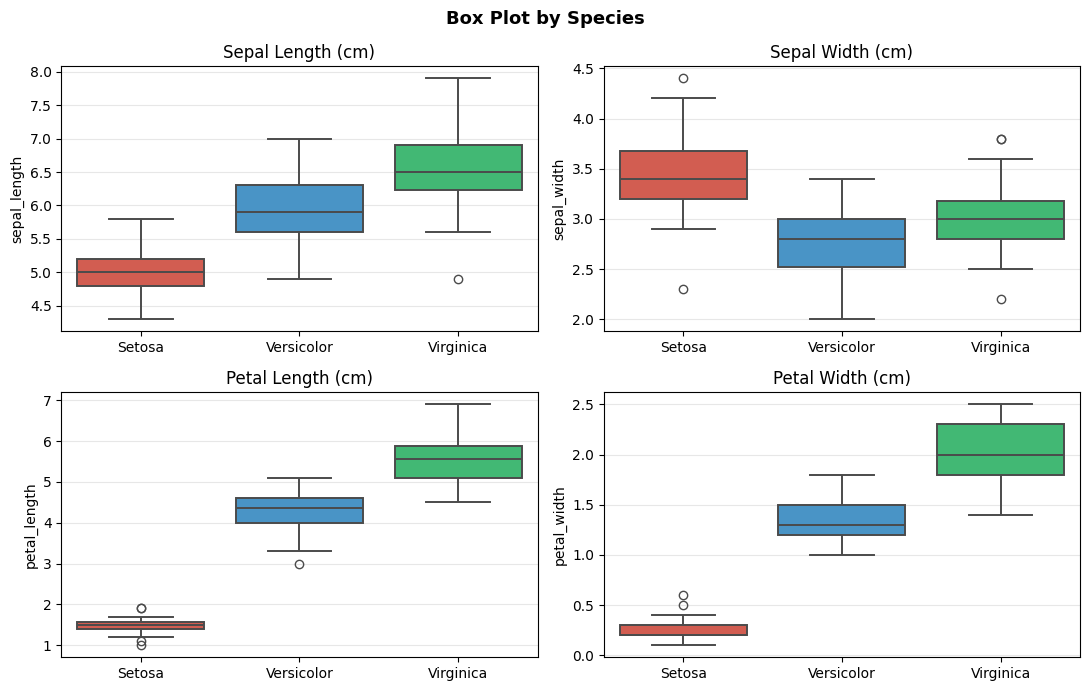

In [8]:
# 박스플롯
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, feat, label in zip(axes.flatten(), FEATURES, feat_labels):
    sns.boxplot(
        data=df, x='species_name', y=feat,
        hue='species_name', palette=COLORS,
        order=['Setosa','Versicolor','Virginica'],
        legend=False, linewidth=1.4, ax=ax
    )
    ax.set_title(label)
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Box Plot by Species', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

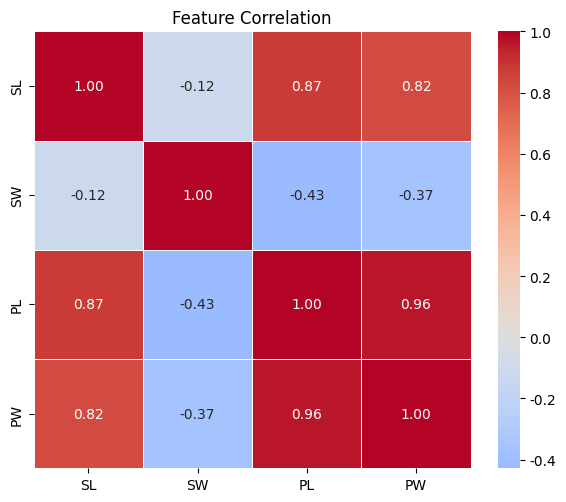

In [9]:
# 상관관계 히트맵
corr = df[FEATURES].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5,
            xticklabels=['SL','SW','PL','PW'],
            yticklabels=['SL','SW','PL','PW'], ax=ax)
ax.set_title('Feature Correlation')
plt.tight_layout()
plt.show()

# petal_length <-> petal_width 상관이 높음 → PCA로 정보 압축이 잘 될 것 같음

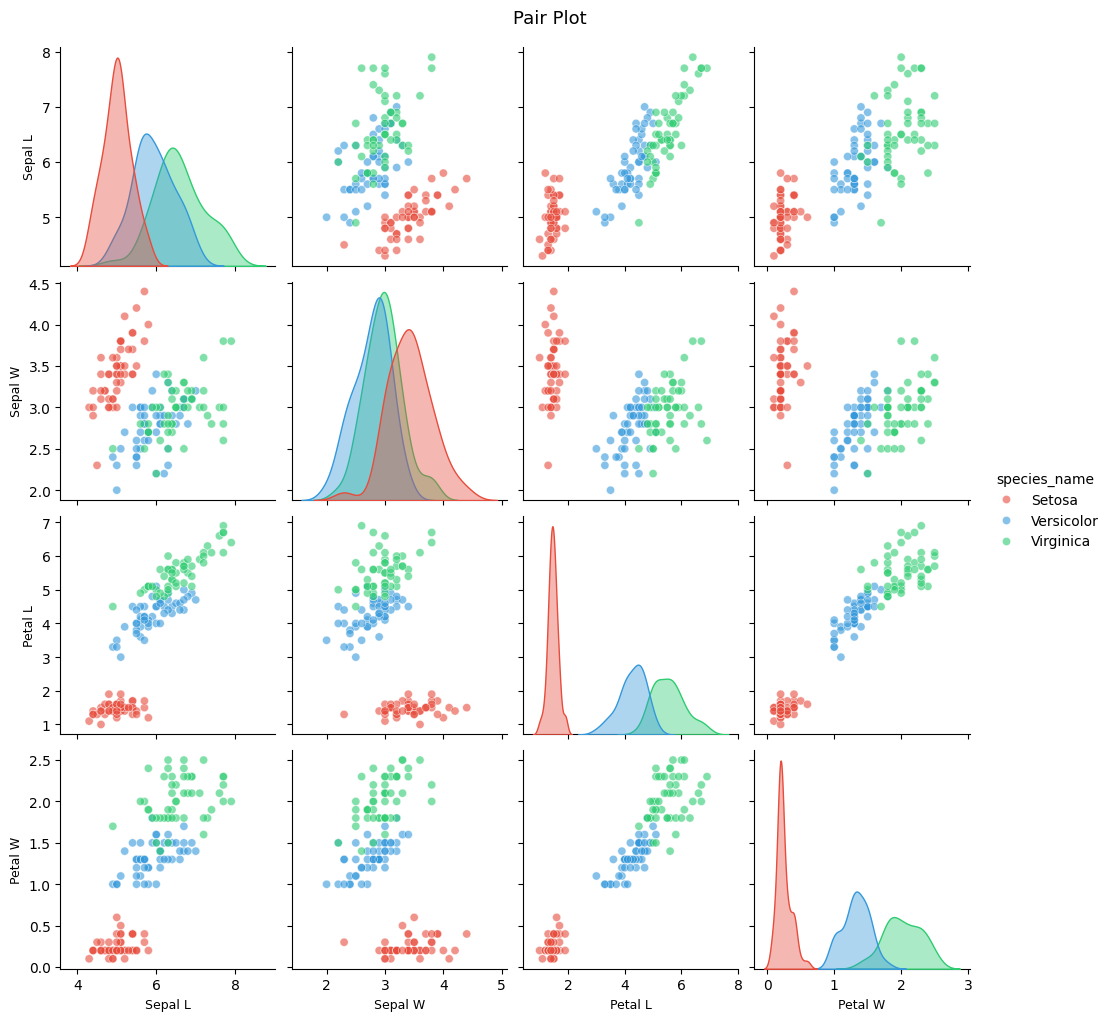

In [10]:
# 페어플롯
pair = sns.pairplot(
    df[FEATURES + ['species_name']],
    hue='species_name', palette=COLORS,
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 35, 'edgecolor': 'white'},
    diag_kws={'fill': True, 'alpha': 0.4}
)
pair.figure.suptitle('Pair Plot', y=1.02, fontsize=13)
short = ['Sepal L','Sepal W','Petal L','Petal W']
for i, ax in enumerate(pair.axes[-1]): ax.set_xlabel(short[i], fontsize=9)
for i, ax in enumerate(pair.axes[:,0]): ax.set_ylabel(short[i], fontsize=9)
plt.show()

## 4. 스케일링 & 데이터 분리

In [11]:
X = df[FEATURES].values
y = df['species'].values

# 스케일링 먼저 — PCA도 스케일링 후에 적용
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# 학습/테스트 분리 (7:3, stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X_std, y, test_size=0.3, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape},  X_test: {X_test.shape}')

X_train: (105, 4),  X_test: (45, 4)


## 5. PCA

PCA는 분산이 최대가 되는 방향으로 축을 새로 정의하는 차원 축소 기법이다.  
스케일링을 먼저 하고 PCA를 적용해야 한다.  
explained_variance_ratio로 각 주성분이 전체 분산을 얼마나 설명하는지 확인.

In [12]:
# PCA 전체 4개 주성분으로 fit
pca = PCA(n_components=4)
pca.fit(X_train)

print('explained_variance_ratio:', pca.explained_variance_ratio_.round(4))
print('cumulative            :', pca.explained_variance_ratio_.cumsum().round(4))

explained_variance_ratio: [0.7184 0.2418 0.0353 0.0045]
cumulative            : [0.7184 0.9602 0.9955 1.    ]


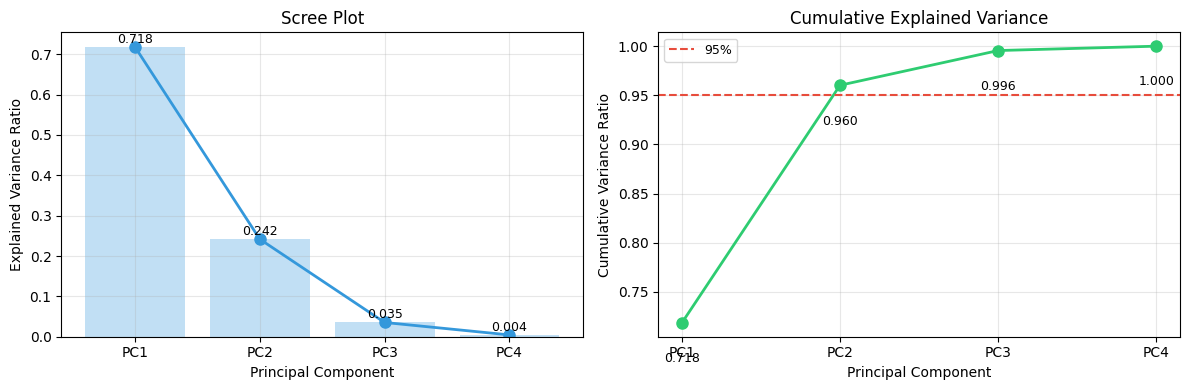

In [13]:
# Scree Plot — 어디까지 쓸지 판단
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pcs = ['PC1', 'PC2', 'PC3', 'PC4']
evr = pca.explained_variance_ratio_

# 개별 분산 비율
axes[0].plot(pcs, evr, 'o-', color='#3498DB', lw=2, ms=8)
axes[0].bar(pcs, evr, alpha=0.3, color='#3498DB')
axes[0].set_title('Scree Plot')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].grid(alpha=0.3)
for i, v in enumerate(evr):
    axes[0].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9)

# 누적 분산 비율
cumsum = evr.cumsum()
axes[1].plot(pcs, cumsum, 'o-', color='#2ECC71', lw=2, ms=8)
axes[1].axhline(0.95, color='#E74C3C', linestyle='--', lw=1.5, label='95%')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Cumulative Variance Ratio')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
for i, v in enumerate(cumsum):
    axes[1].text(i, v-0.04, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# PC1+PC2로 약 97% 설명 → 2개로도 충분할 것으로 예상

In [14]:
# 주성분 로딩 (고유벡터) — 각 피처가 PC에 얼마나 기여하는지
loadings = pd.DataFrame(
    pca.components_.T,
    index=['SL','SW','PL','PW'],
    columns=['PC1','PC2','PC3','PC4']
).round(4)
print(loadings)

       PC1     PC2     PC3     PC4
SL  0.5394  0.3400  0.7199 -0.2742
SW -0.2490  0.9381 -0.2155  0.1077
PL  0.5740  0.0284 -0.1361  0.8070
PW  0.5636  0.0601 -0.6456 -0.5118


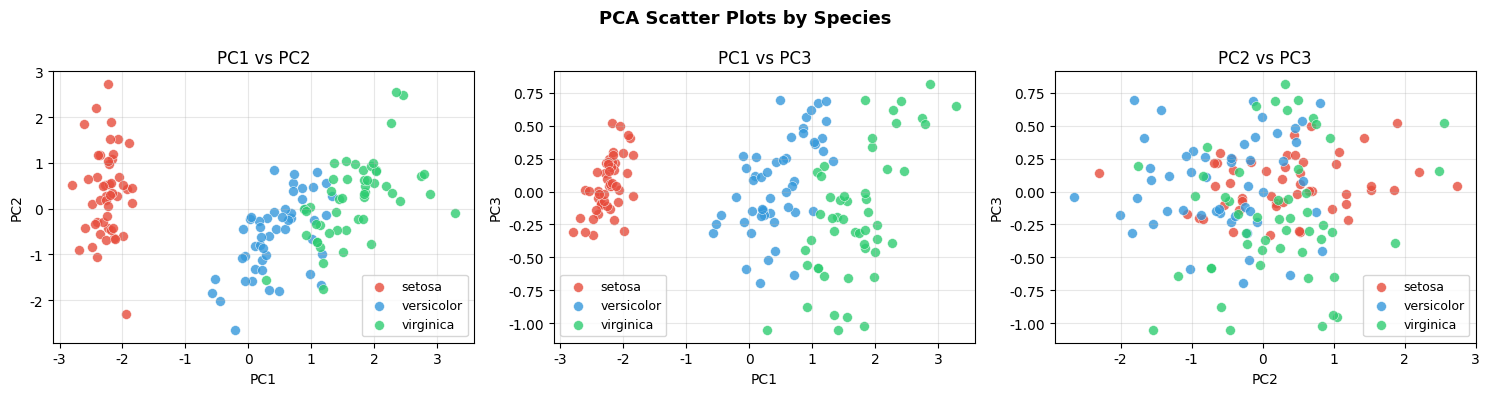

In [15]:
# PC1-PC2 산포도 — 차원 축소 후 분포 확인
X_pca4 = pca.transform(X_std)  # 전체 기준으로 transform

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('PCA Scatter Plots by Species', fontsize=13, fontweight='bold')

combos = [
    (0, 1, 'PC1 vs PC2'),
    (0, 2, 'PC1 vs PC3'),
    (1, 2, 'PC2 vs PC3'),
]
for ax, (xi, yi, title) in zip(axes, combos):
    for label in range(3):
        mask = y == label
        ax.scatter(X_pca4[mask, xi], X_pca4[mask, yi],
                   c=list(COLORS.values())[label],
                   label=iris.target_names[label],
                   s=50, edgecolors='white', linewidth=0.4, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel(f'PC{xi+1}')
    ax.set_ylabel(f'PC{yi+1}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# PC1-PC2에서 이미 Setosa가 완전히 분리됨
# Versicolor / Virginica는 PC1 방향으로 일부 겹침

## 6. KNN 성능 비교

5가지 입력 데이터 구성에 동일한 KNN(k=9, euclidean)을 적용해 정확도를 비교한다.

In [16]:
# 각 조건별 데이터 준비
# PCA는 train에만 fit, test는 transform만

def make_pca_data(n_components, X_tr, X_te):
    p = PCA(n_components=n_components)
    return p.fit_transform(X_tr), p.transform(X_te), p

# 2D 선택 피처 (sepal_width=1, petal_width=3 인덱스)
X_train_2d = X_train[:, [1, 3]]
X_test_2d  = X_test[:, [1, 3]]

# PCA 조건
X_tr_pc2, X_te_pc2, pca2 = make_pca_data(2, X_train, X_test)
X_tr_pc3, X_te_pc3, pca3 = make_pca_data(3, X_train, X_test)
X_tr_pc4, X_te_pc4, pca4 = make_pca_data(4, X_train, X_test)

datasets = [
    ('4D Scaled',         X_train,    X_test),
    ('2D (SW+PW)',        X_train_2d, X_test_2d),
    ('PCA PC1-PC2',       X_tr_pc2,   X_te_pc2),
    ('PCA PC1-PC3',       X_tr_pc3,   X_te_pc3),
    ('PCA PC1-PC4',       X_tr_pc4,   X_te_pc4),
]

print('데이터 구성 확인')
for name, Xtr, Xte in datasets:
    print(f'  {name:<18}: train {Xtr.shape}, test {Xte.shape}')

데이터 구성 확인
  4D Scaled         : train (105, 4), test (45, 4)
  2D (SW+PW)        : train (105, 2), test (45, 2)
  PCA PC1-PC2       : train (105, 2), test (45, 2)
  PCA PC1-PC3       : train (105, 3), test (45, 3)
  PCA PC1-PC4       : train (105, 4), test (45, 4)


In [17]:
# k=9 고정 (KNN 과제 1 최적값)
K = 9
results = []

for name, Xtr, Xte in datasets:
    knn = KNeighborsClassifier(n_neighbors=K, metric='euclidean')
    knn.fit(Xtr, y_train)
    y_pred = knn.predict(Xte)
    acc    = accuracy_score(y_test, y_pred)
    results.append({'Input': name, 'Dims': Xtr.shape[1], 'Accuracy': acc})
    print(f'{name:<18} | dims={Xtr.shape[1]} | acc={acc:.4f}')

result_df = pd.DataFrame(results)

4D Scaled          | dims=4 | acc=0.9556
2D (SW+PW)         | dims=2 | acc=0.9556
PCA PC1-PC2        | dims=2 | acc=0.9111
PCA PC1-PC3        | dims=3 | acc=0.9556
PCA PC1-PC4        | dims=4 | acc=0.9556


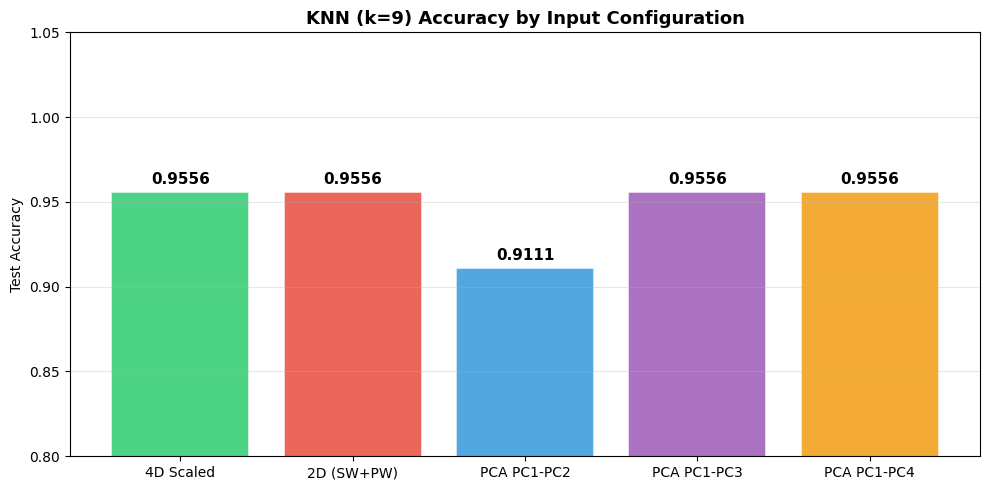

In [18]:
# 정확도 비교 막대 그래프
colors_bar = ['#2ECC71', '#E74C3C', '#3498DB', '#9B59B6', '#F39C12']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(result_df['Input'], result_df['Accuracy'],
              color=colors_bar, alpha=0.85, edgecolor='white', linewidth=1.2)

for bar, acc in zip(bars, result_df['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0.8, 1.05)
ax.set_ylabel('Test Accuracy')
ax.set_title(f'KNN (k={K}) Accuracy by Input Configuration', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

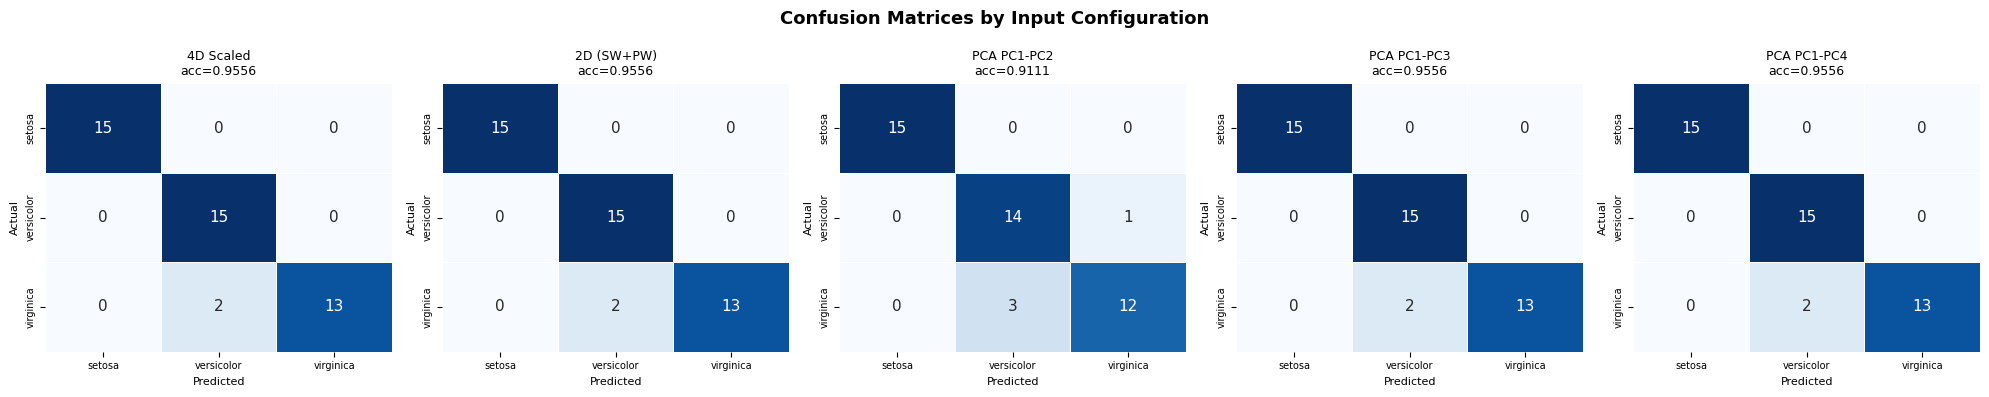

In [19]:
# 혼동 행렬 5개 나란히
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Confusion Matrices by Input Configuration', fontsize=13, fontweight='bold')

for ax, (name, Xtr, Xte), color in zip(axes, datasets, colors_bar):
    knn = KNeighborsClassifier(n_neighbors=K, metric='euclidean')
    knn.fit(Xtr, y_train)
    cm = confusion_matrix(y_test, knn.predict(Xte))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=iris.target_names,
                yticklabels=iris.target_names,
                ax=ax, linewidths=0.5, cbar=False,
                annot_kws={'size': 11})
    acc = cm.diagonal().sum() / cm.sum()
    ax.set_title(f'{name}\nacc={acc:.4f}', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

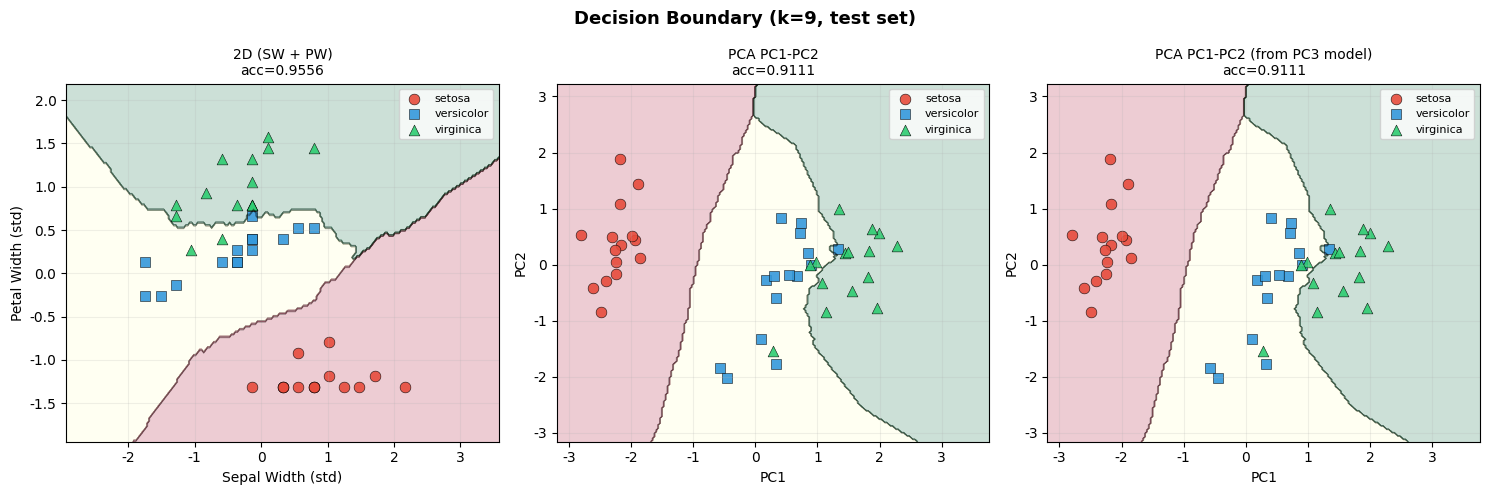

In [20]:
# 결정 경계 비교 — 2D 입력 데이터들만 (PC1-PC2 / 2D 선택 / PCA PC1-PC2)
def plot_boundary(ax, Xtr, Xte, ytr, yte, title):
    knn = KNeighborsClassifier(n_neighbors=K, metric='euclidean')
    knn.fit(Xtr, ytr)

    h = 0.03
    x0_min, x0_max = Xtr[:,0].min()-0.5, Xtr[:,0].max()+0.5
    x1_min, x1_max = Xtr[:,1].min()-0.5, Xtr[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                         np.arange(x1_min, x1_max, h))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    cmap_bg = matplotlib.colormaps.get_cmap('RdYlGn').resampled(3)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='black', linewidths=0.4, alpha=0.4)

    markers = {0:'o', 1:'s', 2:'^'}
    for label in range(3):
        mask = yte == label
        ax.scatter(Xte[mask,0], Xte[mask,1],
                   c=list(COLORS.values())[label],
                   marker=markers[label],
                   label=iris.target_names[label],
                   s=60, edgecolors='black', linewidth=0.4, alpha=0.9)

    acc = knn.score(Xte, yte)
    ax.set_title(f'{title}\nacc={acc:.4f}', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Decision Boundary (k={K}, test set)', fontsize=13, fontweight='bold')

plot_boundary(axes[0], X_train_2d, X_test_2d, y_train, y_test, '2D (SW + PW)')
axes[0].set_xlabel('Sepal Width (std)')
axes[0].set_ylabel('Petal Width (std)')

plot_boundary(axes[1], X_tr_pc2, X_te_pc2, y_train, y_test, 'PCA PC1-PC2')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plot_boundary(axes[2], X_tr_pc3[:,:2], X_te_pc3[:,:2], y_train, y_test, 'PCA PC1-PC2 (from PC3 model)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()

# 2D 선택 피처(SW+PW)는 두 피처 간 분리력이 부족해 경계가 복잡해짐
# PCA PC1-PC2는 분산을 최대로 살려서 경계가 더 깔끔하게 나옴

## 7. 최종 결과 정리

In [21]:
print(result_df.to_string(index=False))
print()
best = result_df.loc[result_df['Accuracy'].idxmax()]
print(f'Best: {best["Input"]}  acc={best["Accuracy"]:.4f}')
print()
print('PC1+PC2만으로도 4D와 동일하거나 근접한 성능을 냄')
print('sepal_width + petal_width 2개만 쓴 경우는 정보 손실이 커서 성능 저하')
print(f'PCA cumulative variance: PC1+PC2={pca.explained_variance_ratio_[:2].sum():.3f}, PC1~PC3={pca.explained_variance_ratio_[:3].sum():.3f}')

      Input  Dims  Accuracy
  4D Scaled     4  0.955556
 2D (SW+PW)     2  0.955556
PCA PC1-PC2     2  0.911111
PCA PC1-PC3     3  0.955556
PCA PC1-PC4     4  0.955556

Best: 4D Scaled  acc=0.9556

PC1+PC2만으로도 4D와 동일하거나 근접한 성능을 냄
sepal_width + petal_width 2개만 쓴 경우는 정보 손실이 커서 성능 저하
PCA cumulative variance: PC1+PC2=0.960, PC1~PC3=0.996
